# Data Load and Exploratory Data Analysis
 
**Assets:** FTSE 100 | GBP/USD | Brent Crude  
**Period:** 2010–2024  

## Objectives
1. Load daily price data from Investing.com (FTSE 100, GBP/USD, Brent Crude)
2. Clean and align price series across all three assets
3. Compute daily log returns and split into training (2010–2022) and test (2023–2024) periods
4. Compute descriptive statistics (mean, std, skewness, excess kurtosis, Jarque-Bera test)
5. Plot return series with crisis period annotations (COVID 2020, Energy Crisis 2022)
6. Analyse rolling pairwise correlations between assets
7. Examine return distributions against the normal distribution
8. Test for stationarity using the Augmented Dickey-Fuller (ADF) test
9. Test for ARCH effects using the Engle LM test
10. Plot ACF of returns and squared returns to confirm volatility clustering
11. Generate Q-Q plots to visualise tail behaviour
12. Plot static correlation heatmap across the training period

In [14]:
import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from src.data_loader import download_prices, compute_log_returns, train_test_split, summary_stats
from scipy import stats as stats_scipy

plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

### 1. Data Loading and Cleaning 
Load raw CSV files from **Investing.com**, parse dates, clean price formats, align all three assets on common trading days, and save a clean prices DataFrame.

In [7]:
import pandas as pd

def load_investing_csv(filepath, asset_name):
    df = pd.read_csv(filepath)
    print(f"\n{asset_name}")
    print(f"  Columns: {df.columns.tolist()}")
    print(f"  Shape:   {df.shape}")
    print(f"  Head:\n{df.head(3)}")
    return df

ftse_raw  = load_investing_csv('../data/raw/FTSE 100 Historical Data.csv', 'FTSE100')
gbp_raw   = load_investing_csv('../data/raw/GBP_USD Historical Data.csv', 'GBPUSD')
brent_raw = load_investing_csv('../data/raw/Brent Oil Futures Historical Data.csv', 'Brent')


FTSE100
  Columns: ['Date', 'Price', 'Open', 'High', 'Low', 'Vol.', 'Change %']
  Shape:   (3787, 7)
  Head:
         Date     Price      Open      High       Low     Vol. Change %
0  12/31/2024  8,173.02  8,121.01  8,180.38  8,096.65  203.36M    0.64%
1  12/30/2024  8,121.01  8,149.78  8,149.78  8,094.88  325.04M   -0.35%
2  12/27/2024  8,149.78  8,136.99  8,151.28  8,112.29  327.26M    0.16%

GBPUSD
  Columns: ['Date', 'Price', 'Open', 'High', 'Low', 'Vol.', 'Change %']
  Shape:   (3913, 7)
  Head:
         Date   Price    Open    High     Low  Vol. Change %
0  12/31/2024  1.2511  1.2548  1.2571  1.2504   NaN   -0.32%
1  12/30/2024  1.2551  1.2571  1.2609  1.2505   NaN   -0.22%
2  12/27/2024  1.2579  1.2523  1.2594  1.2504   NaN    0.43%

Brent
  Columns: ['Date', 'Price', 'Open', 'High', 'Low', 'Vol.', 'Change %']
  Shape:   (3874, 7)
  Head:
         Date  Price   Open   High    Low     Vol. Change %
0  12/31/2024  74.64  74.25  74.89  73.84  190.98K    0.34%
1  12/30/2024  74.39 

In [8]:
def parse_investing_csv(filepath, asset_name):
    df = pd.read_csv(filepath)
    df['Date'] = pd.to_datetime(df['Date'])
    df = df.set_index('Date')
    df = df.sort_index(ascending=True)
    
    # Remove commas from Price column (e.g. "8,173.02" -> 8173.02)
    price = df['Price'].astype(str).str.replace(',', '', regex=False)
    price = pd.to_numeric(price, errors='coerce')
    price.name = asset_name
    return price

ftse  = parse_investing_csv('../data/raw/FTSE 100 Historical Data.csv', 'FTSE100')
gbp   = parse_investing_csv('../data/raw/GBP_USD Historical Data.csv', 'GBPUSD')
brent = parse_investing_csv('../data/raw/Brent Oil Futures Historical Data.csv', 'Brent')

# Combine and keep only rows where all three assets have data
prices = pd.concat([ftse, gbp, brent], axis=1).dropna()

# Filter to our study period
prices = prices.loc['2010-01-01':'2024-12-31']

# Save clean prices
prices.to_csv('../data/raw/prices.csv')

print(f"Shape:      {prices.shape}")
print(f"Date range: {prices.index[0].date()} to {prices.index[-1].date()}")
print(f"\nFirst 3 rows:\n{prices.head(3)}")
print(f"\nLast 3 rows:\n{prices.tail(3)}")

Shape:      (3787, 3)
Date range: 2010-01-04 to 2024-12-31

First 3 rows:
            FTSE100  GBPUSD  Brent
Date                              
2010-01-04   5500.3  1.6095  80.12
2010-01-05   5522.5  1.5995  80.59
2010-01-06   5530.0  1.6023  81.89

Last 3 rows:
            FTSE100  GBPUSD  Brent
Date                              
2024-12-27  8149.78  1.2579  74.17
2024-12-30  8121.01  1.2551  74.39
2024-12-31  8173.02  1.2511  74.64


### 2. Log Returns and Train/Test Split
Compute daily log returns from adjusted closing prices and split into training (2010–2022) and test (2023–2024) periods.

In [9]:
# Compute log returns
returns = compute_log_returns(prices)

# Train/test split
train, test = train_test_split(returns)

print(f"Train: {train.index[0].date()} to {train.index[-1].date()} ({len(train)} obs)")
print(f"Test:  {test.index[0].date()} to {test.index[-1].date()} ({len(test)} obs)")
print(f"\nFirst 3 rows of returns:\n{returns.head(3)}")

Train: 2010-01-05 to 2022-12-30 (3281 obs)
Test:  2023-01-03 to 2024-12-31 (505 obs)

First 3 rows of returns:
             FTSE100    GBPUSD     Brent
Date                                    
2010-01-05  0.004028 -0.006232  0.005849
2010-01-06  0.001357  0.001749  0.016002
2010-01-07 -0.000597 -0.005633 -0.004651


### 3. Summary Statistics
Descriptive statistics for the training period including mean, standard deviation, skewness, excess kurtosis, and Jarque-Bera normality test for each asset.

In [ ]:
stats = summary_stats(train)
print("\nSummary Statistics (Training Period):")
print(stats.to_string())


Summary Statistics (Training Period):
                  FTSE100     GBPUSD      Brent
Mean             0.000093  -0.000087   0.000021
Std Dev          0.010334   0.005821   0.022990
Skewness        -0.684287  -0.986701  -0.971246
Excess Kurtosis  9.567486  15.449191  18.078500
Min             -0.115124  -0.084095  -0.279761
Max              0.086668   0.030953   0.190774
JB p-value       0.000000   0.000000   0.000000


### Summary Statistics Findings

- All three return series exhibit significant departure from normality
  (JB test p < 0.001 for all assets)
- Excess kurtosis ranges from 9.6 (FTSE) to 18.1 (Brent) — heavy tails
  are present in all series
- Negative skewness across all assets confirms asymmetric downside risk
- These findings motivate: (1) Student-t innovations in GARCH models,
  and (2) a Student-t copula to capture joint tail dependence

### 4. Return Series Plots
Time series of daily log returns for all three assets with crisis period annotations for the COVID crash (Feb–May 2020) and 2022 energy crisis.

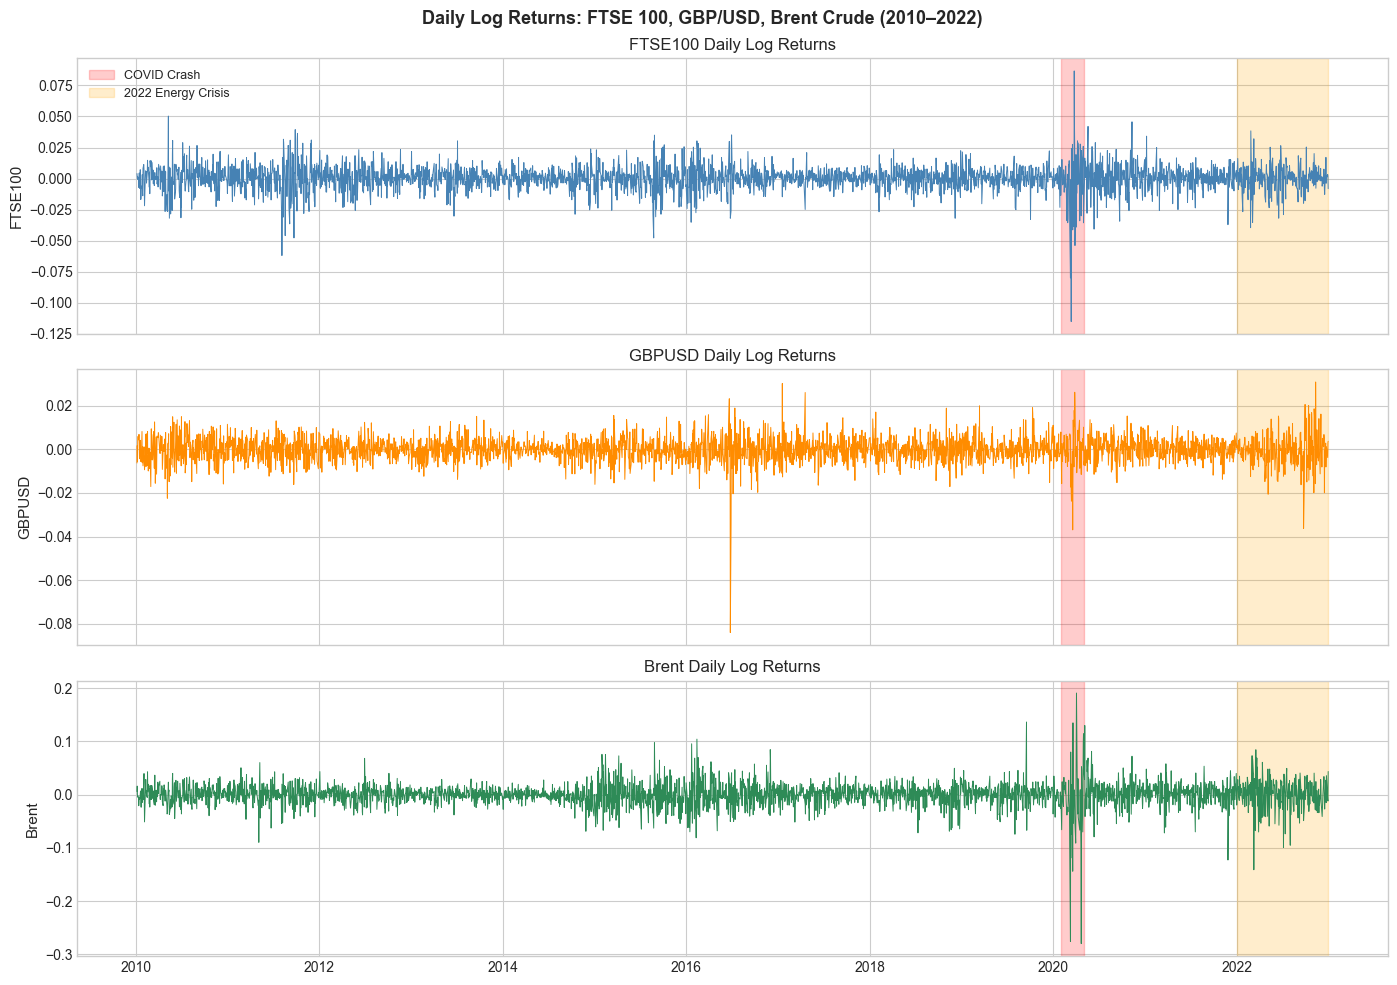

In [11]:

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

for i, col in enumerate(train.columns):
    axes[i].plot(train.index, train[col], linewidth=0.7, color=['steelblue', 'darkorange', 'seagreen'][i])
    axes[i].set_ylabel(col, fontsize=11)
    axes[i].set_title(f'{col} Daily Log Returns', fontsize=12)
    
    # Annotate crisis periods
    axes[i].axvspan(pd.Timestamp('2020-02-01'), pd.Timestamp('2020-05-01'), 
                    alpha=0.2, color='red', label='COVID Crash')
    axes[i].axvspan(pd.Timestamp('2022-01-01'), pd.Timestamp('2022-12-31'), 
                    alpha=0.2, color='orange', label='2022 Energy Crisis')

axes[0].legend(fontsize=9)
plt.suptitle('Daily Log Returns: FTSE 100, GBP/USD, Brent Crude (2010–2022)', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/figures/01_return_series.png', dpi=150, bbox_inches='tight')
plt.show()

### Insights — Return Series

**FTSE 100**
- Volatility clustering is clearly visible — calm periods interrupted by sharp spikes
- The COVID crash (Feb–Mar 2020) produced the largest single-day loss in the sample: approximately -11.5%
- The 2022 period shows elevated but less extreme volatility compared to COVID
- A notable spike around 2011–2012 corresponds to the European sovereign debt crisis

**GBP/USD**
- Generally lower volatility than FTSE and Brent, consistent with the summary statistics (std = 0.58%)
- The extreme negative spike around 2016 is the Brexit referendum result (June 24, 2016) — 
  GBP/USD fell approximately 8% in a single day, visible as the largest outlier in the series
- COVID impact is relatively muted compared to the equity and commodity series

**Brent Crude**
- By far the most volatile asset (std = 2.3%), with frequent large moves throughout the sample
- COVID crash produced the most dramatic episode — Brent collapsed as global demand evaporated,
  with daily losses exceeding 25% at the peak of the crisis (April 2020)
- The 2022 energy crisis shows a sharp positive spike followed by sustained elevated volatility
  as the Russia-Ukraine war disrupted supply

**Cross-asset observation**
- All three assets show simultaneous volatility spikes during the COVID crash window (red band),
  providing early visual evidence of tail dependence — the core motivation for copula modelling
- Outside of crisis periods, the series behave quite differently, suggesting dependence structure
  is regime-dependent

### 5. Rolling Correlation Analysis
60-day rolling pairwise correlations between all three asset pairs to examine time-varying dependence structure and regime-dependent behaviour during crisis periods.

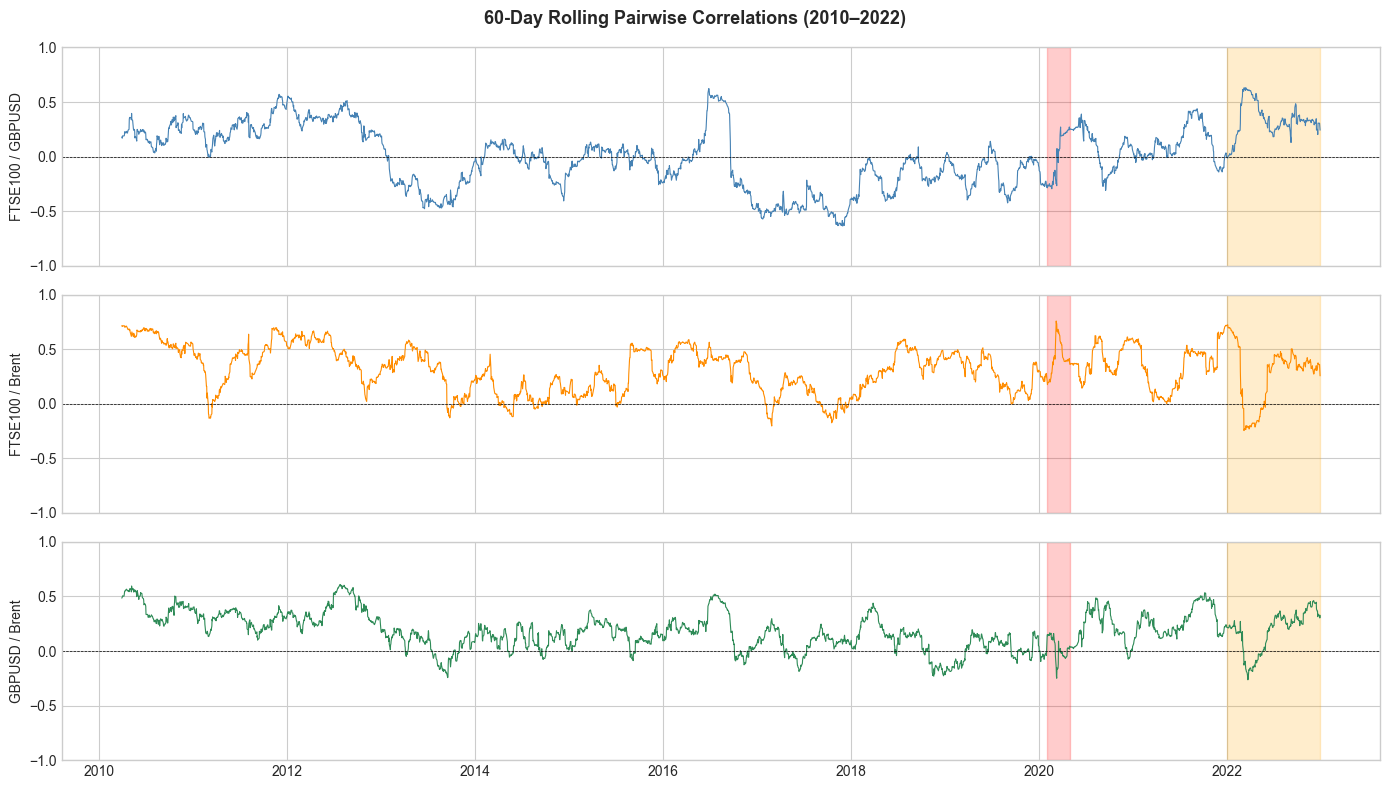

In [12]:
fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)

pairs = [('FTSE100', 'GBPUSD'), ('FTSE100', 'Brent'), ('GBPUSD', 'Brent')]
colors = ['steelblue', 'darkorange', 'seagreen']

for i, (a, b) in enumerate(pairs):
    rolling_corr = train[a].rolling(60).corr(train[b])
    axes[i].plot(rolling_corr.index, rolling_corr, color=colors[i], linewidth=0.8)
    axes[i].axhline(0, color='black', linewidth=0.5, linestyle='--')
    axes[i].set_ylabel(f'{a} / {b}', fontsize=10)
    axes[i].set_ylim(-1, 1)
    
    axes[i].axvspan(pd.Timestamp('2020-02-01'), pd.Timestamp('2020-05-01'),
                    alpha=0.2, color='red')
    axes[i].axvspan(pd.Timestamp('2022-01-01'), pd.Timestamp('2022-12-31'),
                    alpha=0.2, color='orange')

plt.suptitle('60-Day Rolling Pairwise Correlations (2010–2022)', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/figures/02_rolling_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

### Insights — Rolling Pairwise Correlations

**FTSE 100 / GBP-USD**
- The most unstable relationship of the three pairs — correlation oscillates between 
  -0.5 and +0.6 throughout the sample with no stable long-run sign
- This sign-switching reflects the dual role of GBP: in risk-on periods GBP rises with 
  equities, but in risk-off periods GBP weakens as capital flows out of the UK
- The Brexit referendum (2016) caused a structural break — correlation turned sharply 
  negative as FTSE rose (exporters benefiting from weak GBP) while GBP collapsed
- During COVID (red band) correlation briefly spikes then collapses — consistent with 
  a disorderly repricing where normal relationships break down

**FTSE 100 / Brent**
- Broadly positive correlation throughout the sample, reflecting the energy-heavy 
  composition of the FTSE 100 (BP, Shell, energy sector ~15% of index weight)
- Correlation strengthens notably during the 2022 energy crisis (orange band) — 
  FTSE and Brent moved together as energy prices drove both UK inflation and equity returns
- The COVID window shows a sharp spike followed by a collapse — both assets crashed 
  simultaneously in March 2020, producing a brief correlation spike before diverging

**GBP-USD / Brent**
- Moderate positive correlation on average — both respond to global risk appetite 
  (risk-on = strong GBP, high oil demand)
- Correlation turns sharply negative at the start of the 2022 energy crisis — 
  Brent surged on supply shock while GBP weakened on UK inflation concerns, 
  causing these two assets to diverge

**Critical observation for copula modelling**
- None of the three pairwise correlations are stable over time — all three pairs 
  show substantial time variation and regime-dependent behaviour
- This directly motivates the copula framework: a static Gaussian correlation matrix 
  cannot capture this instability, while the Student-t copula captures the tendency 
  for extreme co-movements during crisis periods even when average correlations are low
- The simultaneous volatility spikes across all three assets during COVID (red band) 
  are the clearest evidence of tail dependence in the raw data

### 6. Distribution Analysis
Return histograms with normal overlay and Q-Q plots to visualise fat tails and confirm the departure from normality that motivates Student-t modelling.

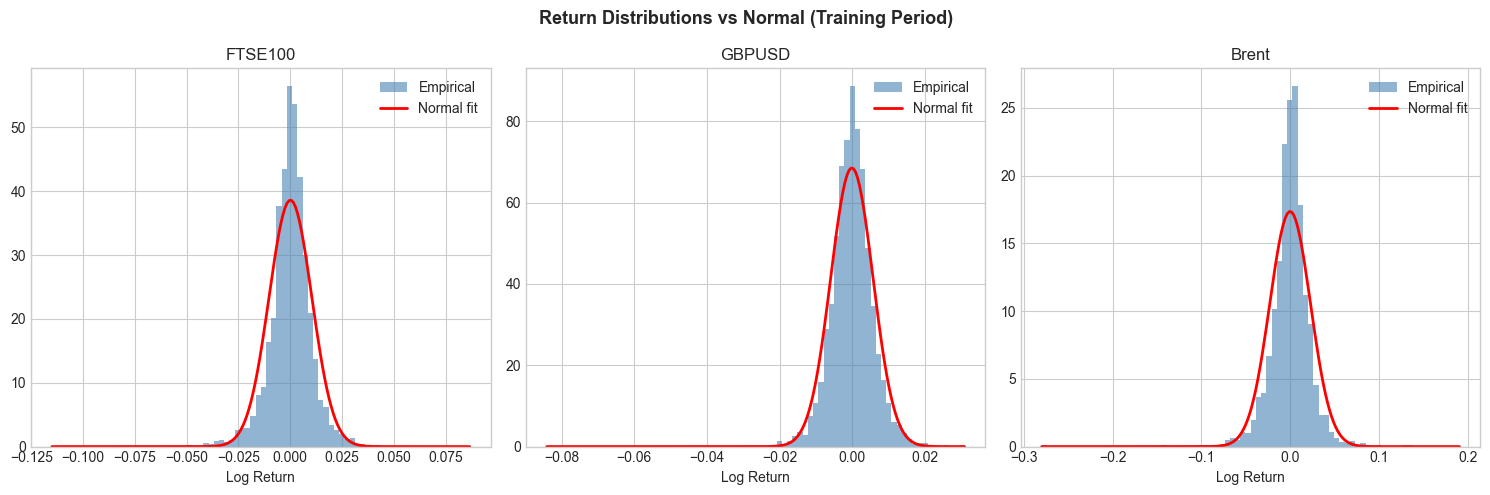

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, col in enumerate(train.columns):
    r = train[col].dropna()
    axes[i].hist(r, bins=80, density=True, color='steelblue', alpha=0.6, label='Empirical')
    
    # Normal overlay
    x = np.linspace(r.min(), r.max(), 200)
    axes[i].plot(x, stats_scipy.norm.pdf(x, r.mean(), r.std()), 
                 'r-', linewidth=2, label='Normal fit')
    
    axes[i].set_title(col, fontsize=12)
    axes[i].set_xlabel('Log Return')
    axes[i].legend()

plt.suptitle('Return Distributions vs Normal (Training Period)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/figures/03_return_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

### Insights — Return Distributions vs Normal

**What the chart shows**
All three empirical distributions (blue) exhibit two clear departures from the 
normal fit (red):

1. **Taller, sharper peak (leptokurtosis)** — the empirical distribution has far 
   more mass concentrated around zero than the normal predicts, consistent with 
   the high excess kurtosis values (9.6, 15.4, 18.1) from the summary statistics

2. **Fatter tails** — extreme returns occur far more frequently than the normal 
   distribution assigns probability to, visible as the empirical bars extending 
   well beyond where the red curve approaches zero

**Asset-level observations**
- FTSE 100 shows the most symmetric fat tails — large positive and negative 
  returns both occur more than normal predicts
- GBP/USD has the sharpest peak relative to the normal — extremely concentrated 
  around zero on most days but with occasional large jumps (Brexit, COVID)
- Brent Crude has the widest spread of all three — large moves in both directions 
  are common, consistent with its volatility being four times that of GBP/USD

**Modelling implication**
The normal distribution systematically underestimates the probability of extreme 
returns for all three assets. This confirms the choice of Student-t innovations 
in the GARCH models and motivates the Student-t copula over the Gaussian copula 
for joint tail risk modelling.

### 7. Autocorrelation and ARCH Effects

ACF of returns and squared returns to confirm volatility clustering, followed by formal stationarity (ADF) and ARCH effects (Engle LM) tests to justify GARCH modelling.

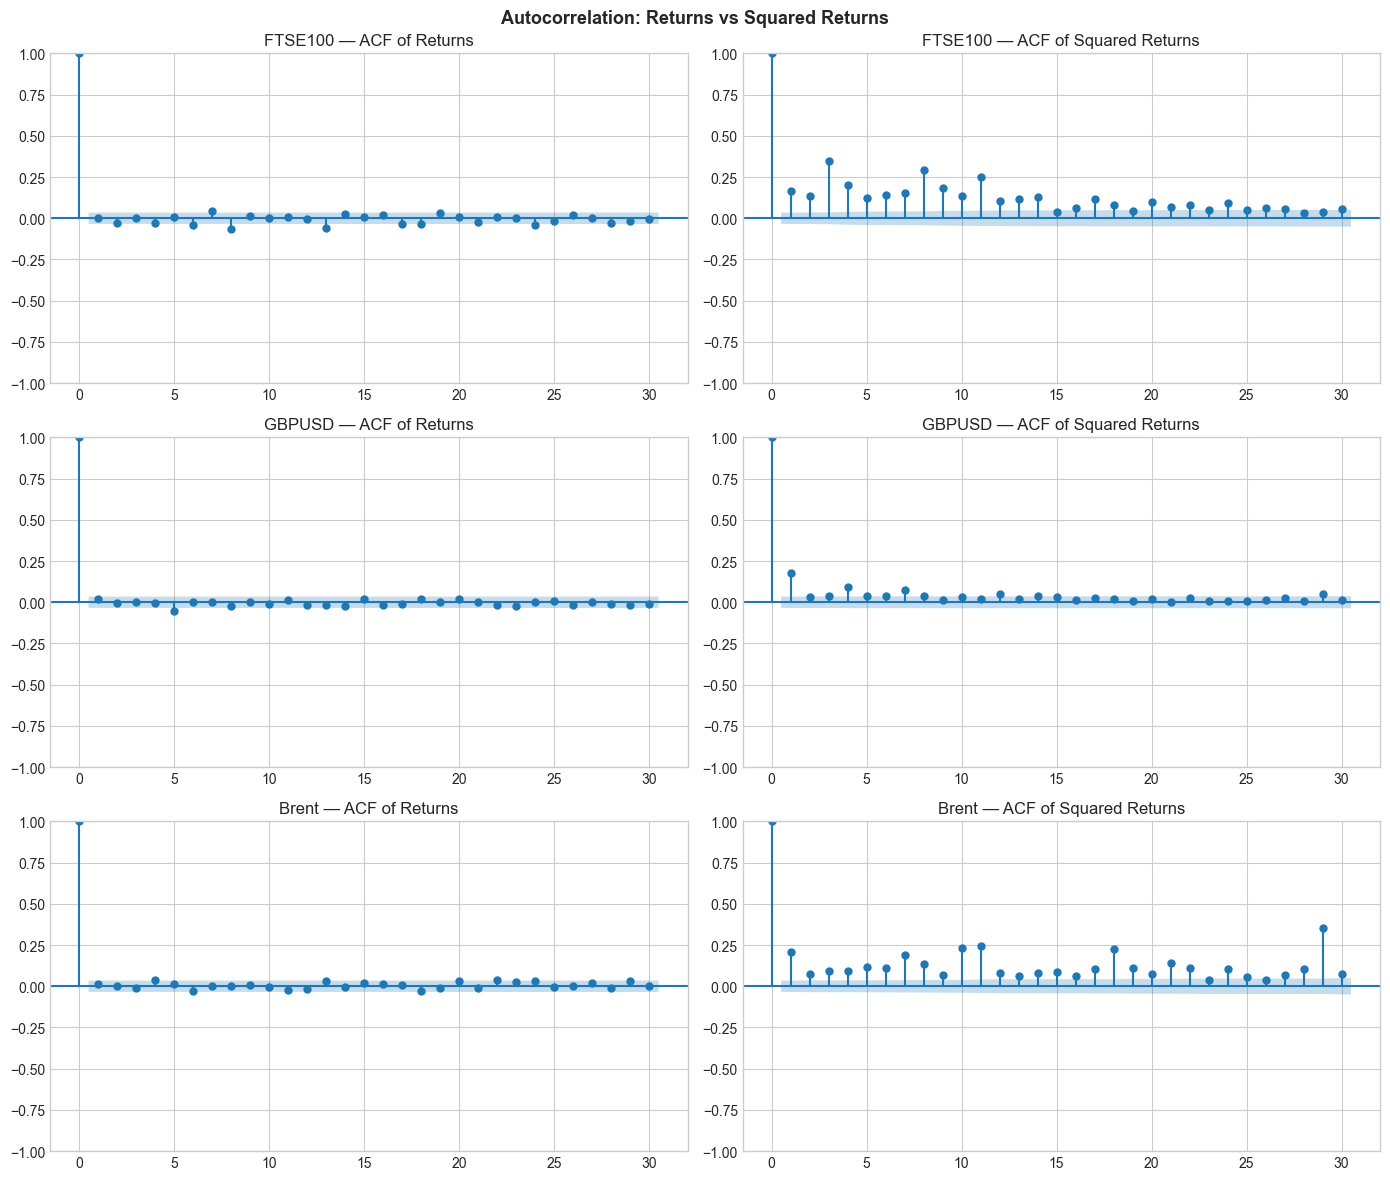

In [16]:
# ACF of returns and squared returns
fig, axes = plt.subplots(3, 2, figsize=(14, 12))

for i, col in enumerate(train.columns):
    r = train[col].dropna()
    plot_acf(r, lags=30, ax=axes[i, 0], title=f'{col} — ACF of Returns')
    plot_acf(r**2, lags=30, ax=axes[i, 1], title=f'{col} — ACF of Squared Returns')

plt.suptitle('Autocorrelation: Returns vs Squared Returns', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/figures/04_acf_plots.png', dpi=150, bbox_inches='tight')
plt.show()

In [17]:
# ADF stationarity test
from statsmodels.tsa.stattools import adfuller

print("Augmented Dickey-Fuller Test (H0: unit root present)\n")
print(f"{'Asset':<12} {'ADF Stat':>10} {'p-value':>10} {'Stationary?':>12}")
print("-" * 48)

for col in train.columns:
    r = train[col].dropna()
    result = adfuller(r, autolag='AIC')
    adf_stat = result[0]
    p_val = result[1]
    stationary = "Yes" if p_val < 0.05 else "No"
    print(f"{col:<12} {adf_stat:>10.4f} {p_val:>10.4f} {stationary:>12}")

Augmented Dickey-Fuller Test (H0: unit root present)

Asset          ADF Stat    p-value  Stationary?
------------------------------------------------
FTSE100        -13.8426     0.0000          Yes
GBPUSD         -26.9741     0.0000          Yes
Brent          -56.5128     0.0000          Yes


In [18]:
# ARCH LM test
from statsmodels.stats.diagnostic import het_arch

print("\n\nARCH LM Test (H0: no ARCH effects)\n")
print(f"{'Asset':<12} {'LM Stat':>10} {'p-value':>10} {'ARCH Effects?':>14}")
print("-" * 50)

for col in train.columns:
    r = train[col].dropna()
    lm_stat, p_val, _, _ = het_arch(r, nlags=10)
    arch = "Yes" if p_val < 0.05 else "No"
    print(f"{col:<12} {lm_stat:>10.4f} {p_val:>10.4f} {arch:>14}")



ARCH LM Test (H0: no ARCH effects)

Asset           LM Stat    p-value  ARCH Effects?
--------------------------------------------------
FTSE100        685.6589     0.0000            Yes
GBPUSD         142.3793     0.0000            Yes
Brent          407.8902     0.0000            Yes


### Insights — Autocorrelation and ARCH Effects

**ACF of Returns**
- All three assets show negligible autocorrelation in raw returns across all 30 lags
- Almost all spikes fall within the 95% confidence bands (shaded blue region)
- This is consistent with the weak-form efficient market hypothesis — past returns 
  have no meaningful linear predictive power for future returns
- Conclusion: a simple AR mean equation is sufficient; no complex lag structure needed

**ACF of Squared Returns**
- Striking contrast — all three assets show strong, persistent autocorrelation 
  in squared returns
- FTSE 100 shows the most persistent clustering with significant spikes across 
  nearly all 30 lags
- Brent Crude also shows strong persistence, consistent with well-documented 
  volatility clustering in commodity markets
- GBP/USD shows the weakest but still clearly significant squared return autocorrelation
- Conclusion: while returns are unpredictable, their volatility is highly predictable — 
  the defining characteristic that GARCH models are designed to capture

**ADF Stationarity Test**
- All three return series strongly reject the unit root null (p = 0.000)
- ADF statistics are large in magnitude (-13.8, -26.9, -56.5), confirming 
  stationarity is not a borderline result
- Log differencing of prices has successfully produced stationary series
- Conclusion: return series are safe to use directly in GARCH estimation

**ARCH LM Test**
- All three assets show highly significant ARCH effects (p = 0.000)
- LM statistics are large — FTSE 100 (685.7) and Brent (407.9) show particularly 
  strong conditional heteroskedasticity
- This formally confirms what the ACF of squared returns showed visually
- Conclusion: GARCH modelling is strongly warranted for all three assets. 
  Proceeding to Notebook 02 for GJR-GARCH estimation.

### 8. Q-Q Plots to visualise tail behaviour
Q-Q plots of standardised returns against the normal distribution to visualise the extent of fat tails in each asset's return distribution.

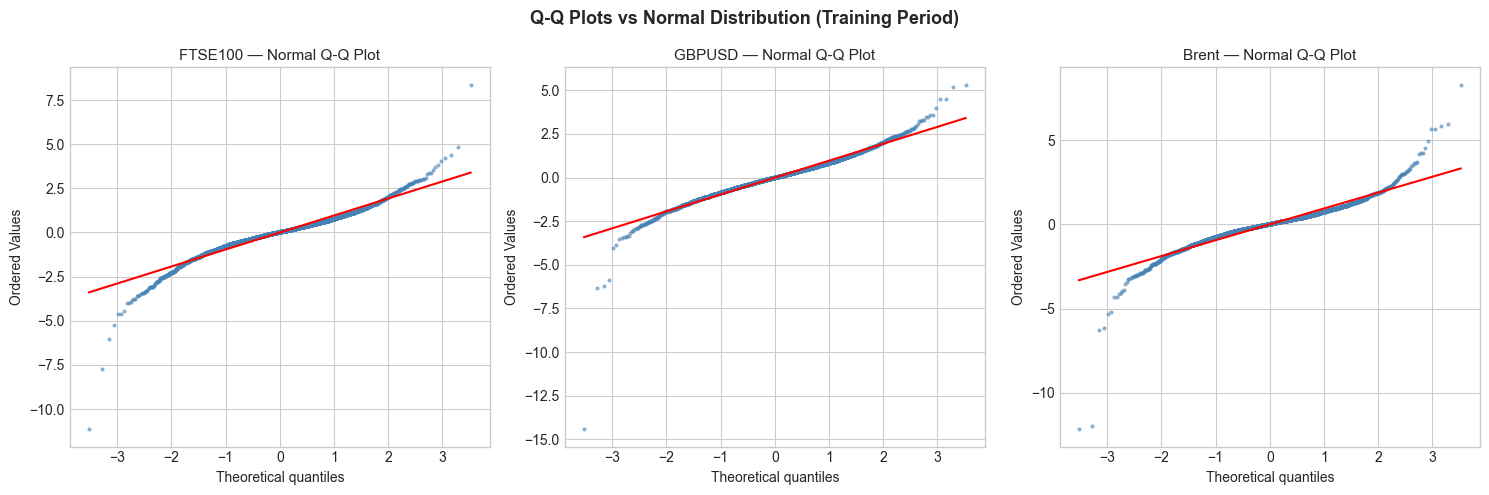

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, col in enumerate(train.columns):
    r = train[col].dropna()
    r_standardised = (r - r.mean()) / r.std()
    
    stats_scipy.probplot(r_standardised, dist='norm', plot=axes[i])
    axes[i].set_title(f'{col} — Normal Q-Q Plot', fontsize=11)
    axes[i].get_lines()[0].set(markersize=2, alpha=0.5, color='steelblue')
    axes[i].get_lines()[1].set(color='red', linewidth=1.5)

plt.suptitle('Q-Q Plots vs Normal Distribution (Training Period)', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/figures/05_qq_plots.png', dpi=150, bbox_inches='tight')
plt.show()

### Insights — Q-Q Plots

**What to look for**

If returns were normally distributed, all points would lie along the red line.
Deviation from the line reveals where and how the normal assumption fails.

**What the plots show**

All three assets display the classic S-curve pattern of a fat-tailed distribution:

- **Lower left tail** — points curve sharply below the red line, meaning extreme 
  negative returns occur far more frequently than the normal predicts
- **Upper right tail** — points curve sharply above the red line, meaning extreme 
  positive returns also occur more than the normal predicts
- **Central region** — points track the red line reasonably well, confirming the 
  normal is adequate only for moderate, everyday returns

**Asset-level observations**
- FTSE 100 shows severe deviation in both tails, with the lower tail extending 
  to nearly -10 standardised units — driven by the COVID crash and 2008 GFC
- GBP/USD shows the most extreme lower tail deviation of all three assets, 
  reaching -15 standardised units — entirely attributable to the Brexit referendum 
  single-day crash which appears as an isolated outlier far from the line
- Brent Crude shows heavy deviation in both tails symmetrically, consistent 
  with its high excess kurtosis of 18.1

**Modelling implication**
The S-curve pattern confirms that a Student-t distribution — which has heavier 
tails controlled by the degrees of freedom parameter — is a far more appropriate 
innovation distribution for GARCH modelling than the normal. This is exactly the 
specification used in Notebook 02.

### 9. Correlation Heatmap

Static pairwise correlation matrix across the full training period as a summary visual of average linear dependence between the three assets.

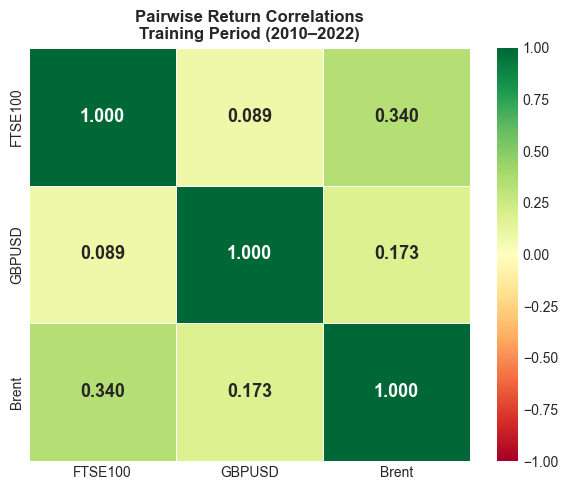

In [20]:
fig, ax = plt.subplots(figsize=(6, 5))

corr = train.corr()

sns.heatmap(corr, annot=True, fmt='.3f', cmap='RdYlGn', center=0,
            vmin=-1, vmax=1, ax=ax, linewidths=0.5,
            annot_kws={'size': 13, 'weight': 'bold'})

ax.set_title('Pairwise Return Correlations\nTraining Period (2010–2022)', 
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/figures/06_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

### Insights — Correlation Heatmap

**Observed correlations (training period average)**
- FTSE 100 / GBP-USD: 0.089 — near zero, very weak positive relationship on average
- FTSE 100 / Brent:   0.340 — moderate positive relationship, strongest of the three pairs
- GBP-USD  / Brent:   0.173 — weak positive relationship

**What this means**
- All three pairwise correlations are positive but low to moderate, suggesting 
  the portfolio has meaningful diversification benefit under normal market conditions
- The near-zero FTSE/GBP correlation (0.089) masks the sign-switching behaviour 
  seen in the rolling correlation chart — averaging across regimes produces a 
  number close to zero that conceals the true dynamic relationship
- The strongest link is FTSE/Brent (0.340), reflecting the energy sector's 
  significant weight in the FTSE 100 index

**Critical limitation of static correlation**
- These average correlations significantly understate tail risk
- As the rolling correlation chart showed, during crisis periods correlations 
  spike sharply — assets that appear weakly correlated on average can move 
  together violently in stress scenarios
- A Gaussian copula calibrated to these static correlations would therefore 
  underestimate the probability of simultaneous large losses across all three assets
- This is precisely the limitation the Student-t copula addresses by explicitly 
  modelling tail dependence independently of average correlation